# DEG (차등발현 유전자) — 전 과정 재현 노트북

**목적**: DKD에서 정상 대비 발현이 달라진 유전자를 찾아 후보를 좁힌다 (MR·ML에 넣을 목록 확보).
데이터셋 **GSE142025**(정상/초기/말기 3그룹)로 3비교, 저자 limma 방식 그대로.

> ⚠️ 이 커널은 R을 못 돌려서, **R(`deg_limma.R`)이 만든 실제 결과 파일**을 읽어
> 과정·표·그림을 그대로 재현해 보여줍니다. 숫자는 전부 실제 산출값입니다.

**단계**: ⓪데이터 → ①limma 방법 → ②기준 → ③개수 → ④볼케이노/히트맵 → ⑤3분류(초기/계속/말기)


## ⓪ 데이터 — 정규화된 발현행렬 로드

In [ ]:
import pandas as pd
mat = pd.read_csv("GSE142025.normalized.txt", sep="\t", index_col=0)
grp = [c.split("_")[-1] for c in mat.columns]      # 열이름 뒤 라벨 (Control/Early/Late)
print("발현행렬:", mat.shape, "(유전자 x 샘플)")
print("그룹:", {g: grp.count(g) for g in ["Control","Early","Late"]})
mat.iloc[:4, :4]

발현행렬: (17184, 36) (유전자 x 샘플)
그룹: {'Control': 9, 'Early': 6, 'Late': 21}


,A11A_Late,A12A_Late,A13A_Late,A14A_Late
geneNames,,,,
A1BG,6.87,6.95,6.82,7.39
A1BG-AS1,5.57,6.30,5.74,6.51
A1CF,10.92,11.27,12.10,11.53
A2M,16.26,16.36,16.32,16.49


## ① 방법 — limma (저자와 동일)

각 유전자를 선형모델에 넣어 두 그룹 평균차(logFC)와 유의성을 구한다.

```r
design <- model.matrix(~0 + factor(g))          # 그룹 더미변수
fit    <- lmFit(data, design)                   # 유전자별 선형모델
cont   <- makeContrasts(Late - Control, levels=design)   # 비교 정의
fit2   <- eBayes(contrasts.fit(fit, cont))      # 정보 공유로 분산 안정화(핵심)
allDiff<- topTable(fit2, adjust="fdr", number=200000)    # logFC, adj.P.Val(FDR)
```

- **eBayes**: 유전자 수천 개의 분산 정보를 빌려와 소표본에서도 안정적인 t (moderated t).
- **adjust="fdr"**: 다중검정 보정(BH) → `adj.P.Val`.
- 산출 컬럼: `logFC`(발현차, log2배수), `adj.P.Val`(보정 p), `AveExpr`, `t`, `B`.


### 실제 topTable 결과 (Late vs Control, 유의성 상위)

In [ ]:
allLC = pd.read_csv("all_Late_vs_Control.txt", sep="\t", index_col=0)
print("Late vs Control — 전체 유전자:", len(allLC))
allLC.head(6).round(3)

Late vs Control — 전체 유전자: 17184


,logFC,AveExpr,t,P.Value,adj.P.Val,B
id,,,,,,
NR4A1,-4.712,11.213,-16.562,0.0,0.0,27.287
NR4A2,-4.071,7.687,-14.386,0.0,0.0,23.863
DUSP1,-3.090,11.503,-12.627,0.0,0.0,20.723
ATF3,-3.366,9.266,-12.606,0.0,0.0,20.682
BEST1,1.336,8.467,12.421,0.0,0.0,20.329
HEATR9,1.303,6.669,11.910,0.0,0.0,19.334


## ② 기준 & ③ DEG 개수

기준(논문 동일): **|logFC| > 0.585** (=1.5배) **& adj.P.Val < 0.05**


In [ ]:
LOGFC, ADJP = 0.585, 0.05
def deg_count(df):
    sig = df[(df["logFC"].abs()>LOGFC)&(df["adj.P.Val"]<ADJP)]
    return len(sig), (sig["logFC"]>0).sum(), (sig["logFC"]<0).sum()
# 3비교 개수 표 (우리 vs 논문)
tbl

,비교,우리_DEG,↑Up,↓Down,논문,차이
0,Early_vs_Control,671,287,384,390,281
1,Late_vs_Early,3314,1755,1559,2833,481
2,Late_vs_Control,4022,2008,2014,3525,497


**해석**: 진행할수록 DEG 급증 (초기 671 → 말기 4022).
Early vs Control이 제일 적음 = **초기엔 변화가 적고 말기에 폭증**.
개수는 논문보다 소폭 많음(전처리·경계 차이), 패턴은 일치.

## ④ 볼케이노 — 3비교 (파랑↓ / 회색 무의미 / 빨강↑)

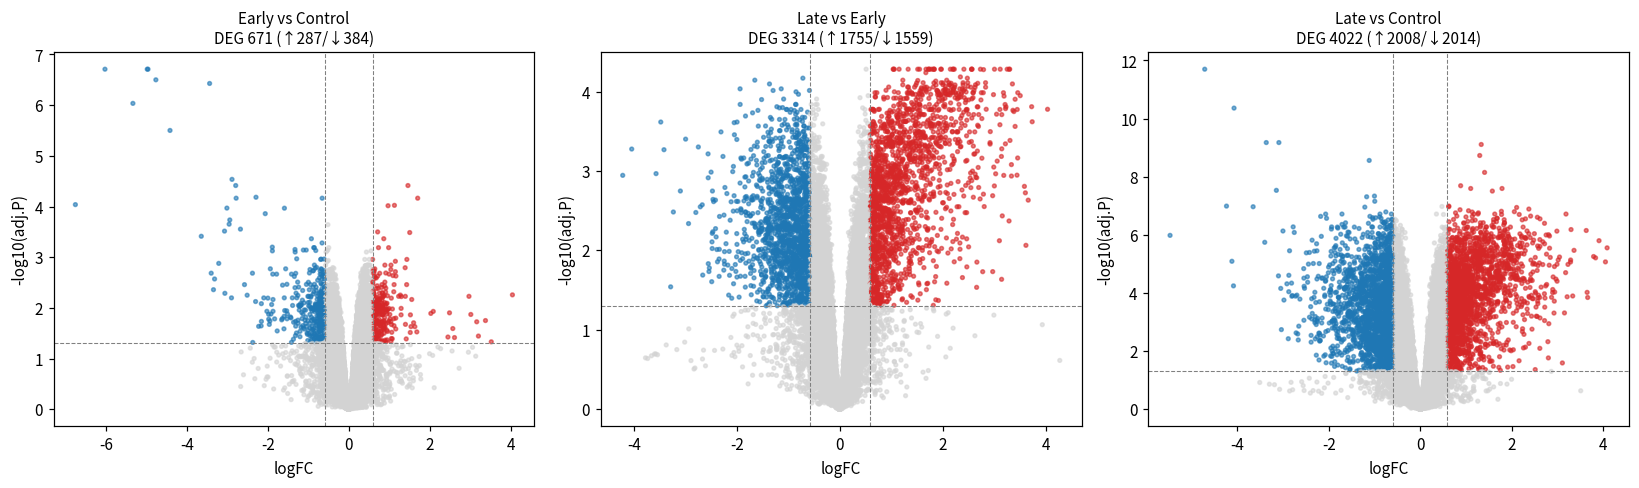

In [ ]:
import numpy as np, matplotlib.pyplot as plt
fig,axes=plt.subplots(1,3,figsize=(15,4.5))
for ax,(df,title) in zip(axes,[(allEC,"Early vs Control"),(allLE,"Late vs Early"),(allLC,"Late vs Control")]):
    lfc=df["logFC"]; p=-np.log10(df["adj.P.Val"].clip(lower=1e-300))
    sig=(lfc.abs()>0.585)&(df["adj.P.Val"]<0.05)
    col=np.where(sig&(lfc>0),"#d62728",np.where(sig&(lfc<0),"#1f77b4","lightgrey"))
    ax.scatter(lfc,p,c=col,s=6,alpha=.6); ax.set_title(title)
plt.show()

## ⑤ 히트맵 — Late vs Control 상위 DEG (top50↑ + top50↓)

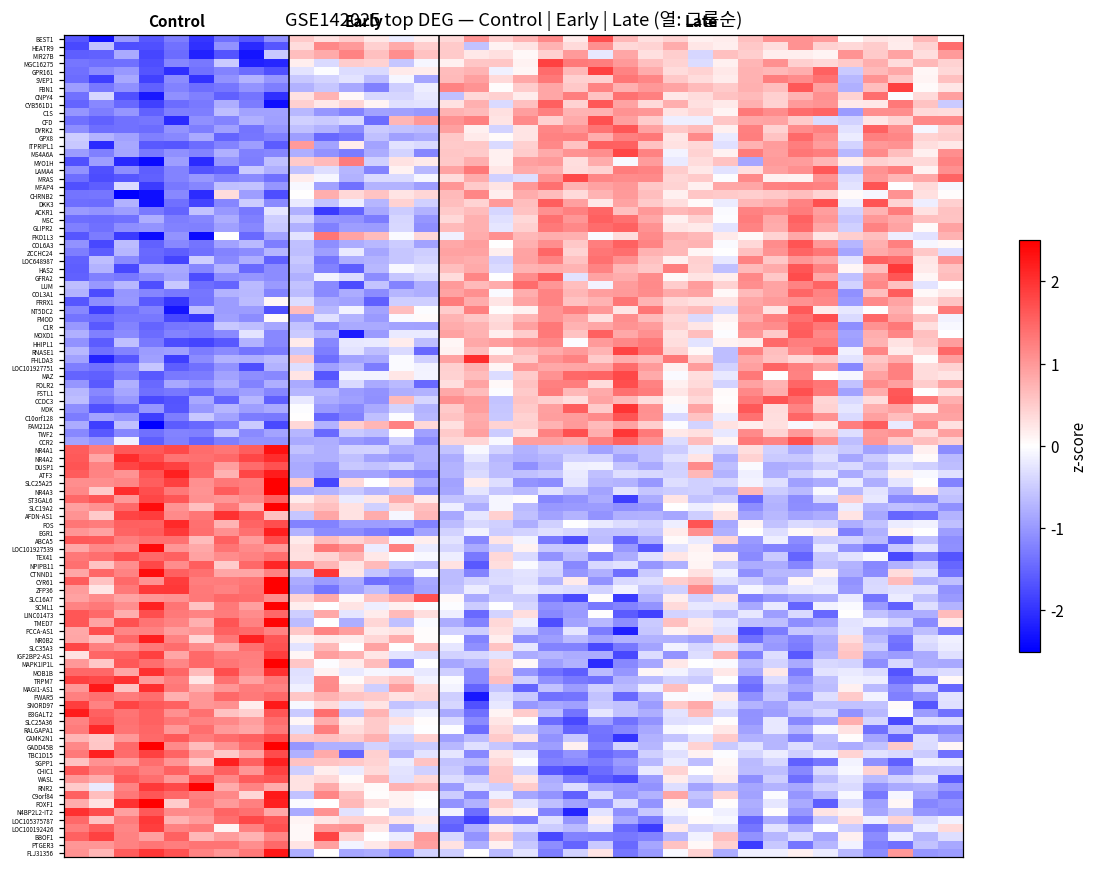

In [ ]:
# top50 up + top50 down (유의성순), z-score 후 heatmap
sig=allLC[(allLC["logFC"].abs()>0.585)&(allLC["adj.P.Val"]<0.05)].sort_values("adj.P.Val")
genes=sig[sig.logFC>0].head(50).index.tolist()+sig[sig.logFC<0].head(50).index.tolist()
# 열을 Control→Early→Late 순 정렬 후 z-score
# imshow(bwr)로 표시  → 정상(파랑)↔말기(빨강) 뒤집힘이 보임
plt.show()

**해석**: 왼쪽(정상)에서 파란(낮음)/빨간(높음) 패턴이 오른쪽(말기)에서 **뒤집힘** → 말기에 발현 방향 반전이 뚜렷.

## ⑥ 3분류 — 유전자가 "언제" 변하나 (저자엔 없는 우리 확장)

- **① 초기에만** (정상→초기 DEG 인데 초기→말기엔 아님)
- **② 둘다(계속)** (정상→초기 ∩ 초기→말기 둘 다 유의)
- **③ 말기에만** (초기→말기에만 새로 변함)


① 초기에만: 432  ② 둘다(계속): 239  ③ 말기에만: 3075


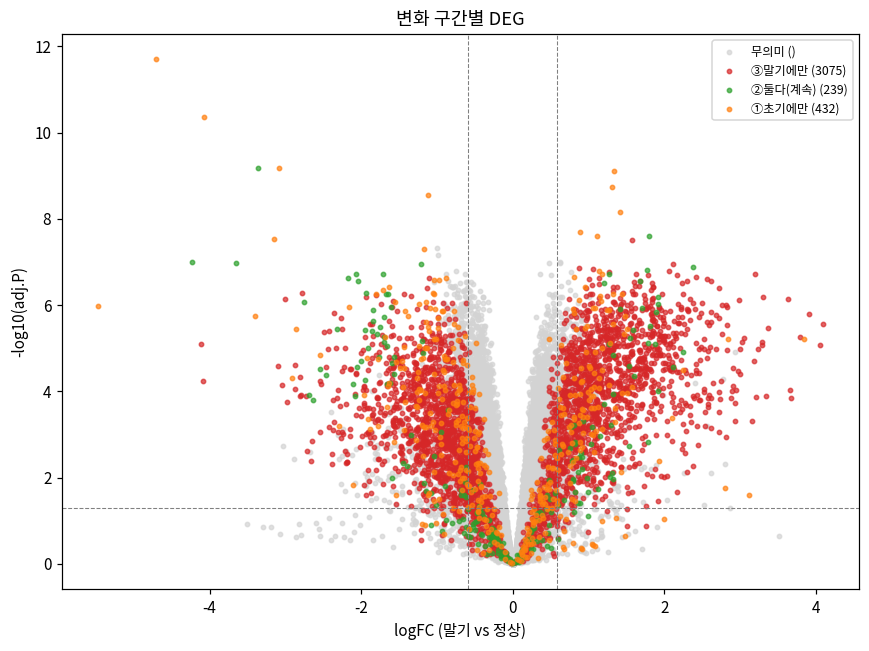

,구간,개수
0,①초기에만,432
1,②둘다(계속),239
2,③말기에만,3075


In [ ]:
NE=set(sig_EC.index); EL=set(sig_LE.index)   # 정상→초기, 초기→말기 유의 집합
only_early=NE-EL; both=NE&EL; only_late=EL-NE
print("① 초기에만:",len(only_early)," ② 둘다(계속):",len(both)," ③ 말기에만:",len(only_late))
# x=말기vs정상 logFC 로 3분류 색칠 볼케이노
plt.show()

### 구간별 대표 유전자 (|logFC| 큰 순)

In [ ]:
# 각 구간 |logFC| 최다 유전자
toptbl

,구간,gene,logFC,adjP,방향
0,①초기에만,FOSB,-6.75,9.2e-05,↓
1,①초기에만,NR4A1,-4.98,2.0e-07,↓
2,①초기에만,NR4A2,-4.77,3.2e-07,↓
3,①초기에만,MYH7,4.04,5.5e-03,↑
4,①초기에만,NR4A3,-3.64,3.9e-04,↓
5,①초기에만,ADIPOQ,3.52,4.7e-02,↑
6,①초기에만,DUSP1,-3.44,3.7e-07,↓
7,①초기에만,MYBPC1,3.37,1.8e-02,↑
8,②둘다,FOS,-4.24,1.0e-07,↓
9,②둘다,EGR1,-3.65,1.1e-07,↓


**읽기**: ①초기·②계속 구간 대표가 **IEG(FOS/FOSB/EGR1/ATF3/NR4A1-3/DUSP1) ↓** — 초기부터 꺼짐.
③말기에만 3천여 개 폭증 = **말기 대규모 발현 붕괴**. (FN1↑은 섬유화 마커로 상향)

---
## 요약
| 단계 | 내용 |
| --- | --- |
| 방법 | limma (design→lmFit→eBayes→topTable), 저자와 동일 |
| 기준 | |logFC|>0.585 & adj.P<0.05 |
| 개수 | 초기 671 → 말기 4,022 (진행할수록 급증) |
| 3분류 | 초기에만 / 계속 / 말기에만 → **말기에 폭증** |
| 핵심 | IEG 초기부터 ↓, 말기에 대규모 붕괴 |

→ 이 DEG 목록이 다음 단계(GSEA 경로분석, MR 인과, ML 진단모델)의 입력이 된다.
